# QAOA Depth and Noise Study

This notebook evaluates how QAOA performance evolves with circuit depth and how hardware-inspired noise degrades the expectation value.


> Environment note
>
> This notebook assumes that the project dependencies listed in `requirements.txt` are already installed.


In [1]:
import sys
import os

# 1. Move up one level to /home/rmnbm/quant_algo/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 2. Add that root to Python's search list
if project_root not in sys.path:
    sys.path.append(project_root)


In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from solver.quantum_solver.qaoa_solver.qaoa_optimizer import QAOALocalOptimizer


In [3]:
# Setup the problem and simulator
s1, s2, s3, s4, s5, s6 = sp.symbols('s1 s2 s3 s4 s5 s6')
n_qubits = 6
problem = s1*s2 + s2*s3 + s3*s4 + s4*s5 + s5*s6 # Small test instance 
sim_ideal = AerSimulator()

#Test different depths (p) [cite: 117]
p_values = [1, 2, 3, 4]
results = []

for p in p_values:
    optimizer = QAOALocalOptimizer(sim_ideal, (0, np.pi), (0, np.pi), p, 1024, 'COBYLA')
    best_cost, _ = optimizer.optimize(problem, p) 
    results.append(best_cost)


In [4]:
# Add a noise model
noise_model = NoiseModel()
error = depolarizing_error(0.01, 1) # 1% error
noise_model.add_all_qubit_quantum_error(error, ['rx', 'rz', 'sx'])
sim_noisy = AerSimulator(noise_model=noise_model)

optimizer_noisy = QAOALocalOptimizer(sim_noisy, (0, np.pi), (0, np.pi), 1, 1024, 'COBYLA')
noisy_cost, _ = optimizer_noisy.optimize(problem, 1)


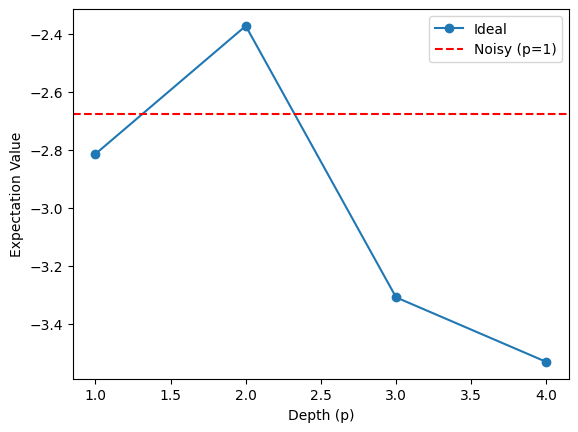

In [5]:
# Visualize the results
plt.plot(p_values, results, marker='o', label='Ideal')
plt.axhline(y=noisy_cost, color='r', linestyle='--', label='Noisy (p=1)')
plt.xlabel('Depth (p)')
plt.ylabel('Expectation Value')
plt.legend()
plt.show()
